In [1]:
import numpy as np
import networkx as nx
import scipy.linalg
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import matplotlib.pyplot as plt
from itertools import combinations
import torch.optim as optim
from sklearn.metrics import roc_auc_score
import scipy.stats
from scipy.linalg import eigvalsh


In [2]:

# --- 1. GNN 模型定义 (用于预测 / Learned Scoring) ---

class GeneralizableGNNScorer(nn.Module):
    def __init__(self, input_dim, hidden_dim=32):
        super(GeneralizableGNNScorer, self).__init__()
        # 移除 nn.Embedding，改为线性层处理通用特征
        self.lin1 = nn.Linear(input_dim, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, hidden_dim)

        self.score_mlp = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
            nn.Sigmoid()
        )

    def forward(self, adj, node_features, edge_candidates_indices):
        """
        node_features: (N, input_dim) 通用特征，如度数或常数
        """
        # 简单归一化
        deg = adj.sum(dim=1, keepdim=True).clamp(min=1)

        # GCN Conv 1
        x = torch.matmul(adj / deg, node_features)
        x = F.relu(self.lin1(x))

        # GCN Conv 2
        x = torch.matmul(adj / deg, x)
        x = self.lin2(x)

        # 评分
        u_idx = edge_candidates_indices[:, 0]
        v_idx = edge_candidates_indices[:, 1]
        edge_feat = torch.cat([x[u_idx], x[v_idx]], dim=1)

        return self.score_mlp(edge_feat).squeeze()


In [3]:
def train_edge_predictor(graph_list, epochs=50, lr=0.01):
    """
    单独训练边数预测器 (Log Space)
    """
    model = LogEdgeCountPredictor()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    print(f"--- 阶段 1.1: 独立训练边数预测器 ({len(graph_list)} graphs) ---")

    # 预处理数据：提取所有图的 (log_N, log_E) 对，转为 Tensor
    # 这样训练时不需要再遍历图对象，速度极快
    data_x = []
    data_y = []
    for G in graph_list:
        n = G.number_of_nodes()
        e = G.number_of_edges()
        if n < 2: continue
        data_x.append(float(n))
        data_y.append(float(e))

    # 转为 Log 空间 Tensor
    tensor_x = torch.log(torch.tensor(data_x).unsqueeze(1) + 1.0)
    tensor_y = torch.log(torch.tensor(data_y).unsqueeze(1) + 1.0)

    # 创建 DataLoader (可选，这里数据少直接全量训练或简单Batch)
    batch_size = 100
    num_samples = len(tensor_x)

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()

        # 简单的 Batch 采样
        indices = np.random.choice(num_samples, size=min(batch_size, num_samples), replace=False)
        batch_x = tensor_x[indices]
        batch_y = tensor_y[indices]

        pred_y = model.mlp(batch_x) # 注意这里直接调用 mlp，因为输入已经是 log 了
        loss = loss_fn(pred_y, batch_y)

        loss.backward()
        optimizer.step()

        if epoch % 10 == 0:
            # 计算真实误差 RMSE
            with torch.no_grad():
                pred_real = torch.exp(pred_y) - 1.0
                true_real = torch.exp(batch_y) - 1.0
                rmse = torch.sqrt(torch.mean((pred_real - true_real)**2))
            print(f"Epoch {epoch}: Log Loss={loss.item():.4f}, Real Edge RMSE={rmse:.2f}")

    return model

In [4]:
def train_gnn_scorer(graph_list, hidden_dim=32, epochs=50, lr=0.005):
    """
    单独训练 GNN 结构预测
    """
    feature_dim = 50
    graph_list = list(graph_list)
    num_graphs = len(graph_list)

    model = GeneralizableGNNScorer(input_dim=feature_dim, hidden_dim=hidden_dim)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    print(f"--- 阶段 1.2: 独立训练 GNN 结构预测 ---")

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        batch_loss_count = 0

        batch_size = min(50, num_graphs)
        batch_indices = np.random.choice(num_graphs, size=batch_size, replace=False)
        batch_graphs = [graph_list[i] for i in batch_indices]

        optimizer.zero_grad()

        for G in batch_graphs:
            # ... (此处保留原有的 GNN 数据构建代码: feats, adj, pos/neg samples) ...
            # ... 为了节省篇幅，这里指代原本 train_gnn_and_predictor 中 "Task 2" 的部分 ...

            # --- 以下是核心逻辑 ---
            # 1. 构建特征和邻接矩阵
            num_nodes = G.number_of_nodes()
            if num_nodes < 5: continue
            feats = get_degree_features(G, feature_dim=feature_dim)

            # 2. 构建正负样本 (模拟稀疏化)
            all_edges = set(G.edges())
            all_possible = set(combinations(range(num_nodes), 2))
            non_edges = list(all_possible - all_edges)

            num_edges = len(all_edges)
            if num_edges > 0:
                keep_indices = np.random.choice(num_edges, max(1, int(num_edges*0.4)), replace=False)
                input_edges = [list(all_edges)[i] for i in keep_indices]
            else:
                input_edges = []

            adj_input = torch.zeros((num_nodes, num_nodes))
            for u, v in input_edges:
                adj_input[u, v] = 1; adj_input[v, u] = 1

            # 正样本
            current_edge_set = set([(u,v) for u,v in input_edges] + [(v,u) for u,v in input_edges])
            pos_edges = [e for e in all_edges if e not in current_edge_set and (e[1], e[0]) not in current_edge_set]

            if len(pos_edges) == 0: continue

            # 负样本
            neg_sample_size = min(len(non_edges), len(pos_edges))
            if neg_sample_size == 0: continue
            neg_indices = np.random.choice(len(non_edges), neg_sample_size, replace=False)
            neg_edges = [non_edges[i] for i in neg_indices]

            train_edges = pos_edges + neg_edges
            train_labels = torch.cat([torch.ones(len(pos_edges)), torch.zeros(len(neg_edges))])
            train_indices = torch.tensor(train_edges, dtype=torch.long)

            # 3. 前向传播与 Loss
            preds = model(adj_input, feats, train_indices)
            loss = F.binary_cross_entropy(preds, train_labels)

            loss.backward()
            total_loss += loss.item()
            batch_loss_count += 1

        if batch_loss_count > 0:
            optimizer.step()

        if epoch % 10 == 0 and batch_loss_count > 0:
            print(f"Epoch {epoch}: GNN BCE Loss={total_loss / batch_loss_count:.4f}")

    return model, feature_dim

In [5]:
class LogEdgeCountPredictor(nn.Module):
    def __init__(self):
        super(LogEdgeCountPredictor, self).__init__()
        # 输入: log(num_nodes) -> 输出: log(num_edges)
        # 这种关系在社交网络中通常近似线性
        self.mlp = nn.Sequential(
            nn.Linear(1, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, num_nodes):
        # 输入前取 log (加1防止log(0))
        log_n = torch.log(torch.tensor([[float(num_nodes)]], dtype=torch.float32) + 1.0)
        return self.mlp(log_n)

In [6]:
def get_degree_features(graph, feature_dim=50):
    """
    辅助函数：为图生成通用的度数 One-Hot 特征
    """
    num_nodes = graph.number_of_nodes()
    # 获取度数
    degrees = [d for n, d in graph.degree()]

    # 构建特征矩阵 (N, feature_dim)
    feats = torch.zeros(num_nodes, feature_dim)
    for i, d in enumerate(degrees):
        # 截断超过维度的度数
        idx = min(d, feature_dim - 1)
        feats[i, idx] = 1.0

    return feats

In [7]:

# --- 2. 数据加载器 ---

def load_deezer_dataset(url="hf://datasets/graphs-datasets/deezer_ego_nets/data/full-00000-of-00001-0696af9ab51b91da.parquet", limit=5):
    """
    加载 Deezer Ego-nets 数据集并转换为 NetworkX 对象 (修复版)
    """
    print(f"正在从 Hugging Face 加载数据: {url} ...")
    try:
        df = pd.read_parquet(url)
    except Exception as e:
        print(f"加载失败: {e}")
        return []

    graphs = []
    print(f"数据加载成功，共 {len(df)} 行。正在解析前 {limit} 个图...")

    for i, row in df.iterrows():
        if i >= limit: break

        edges = []
        # 稳健处理 edge_index
        if 'edge_index' in row:
            raw_edge_index = row['edge_index']

            # 检查是否为 PyG 标准格式 [[src...], [dst...]]
            # 这种格式特征是：是一个列表/数组，长度为2，且第一个元素也是列表/数组（且长度通常大于2或等于边数）
            if (isinstance(raw_edge_index, (list, np.ndarray)) and
                len(raw_edge_index) == 2 and
                isinstance(raw_edge_index[0], (list, np.ndarray, np.generic))):

                # 使用 zip 将 [[src...], [dst...]] 转换为 [(src, dst), ...]
                # 这种方法不依赖 numpy 维度猜测，最为安全
                try:
                    src_list = raw_edge_index[0]
                    dst_list = raw_edge_index[1]
                    edges = list(zip(src_list, dst_list))
                except Exception as e:
                    print(f"解析 edge_index 失败 (Row {i}): {e}")
                    edges = []
            else:
                # 假设已经是边列表格式 [(u,v), ...]
                edges = raw_edge_index

        elif 'src' in row and 'dst' in row:
             edges = list(zip(row['src'], row['dst']))

        # 创建 NetworkX 图
        G = nx.Graph()

        # 尝试获取节点数量以添加孤立点
        num_nodes = 0
        if 'num_nodes' in row and row['num_nodes'] is not None:
            num_nodes = row['num_nodes']
        elif 'x' in row and row['x'] is not None:
            num_nodes = len(row['x'])
        elif edges:
            # 如果没有显式节点数，取边中最大的节点索引+1
            import itertools
            # 展平边列表以找到最大ID
            flat_nodes = list(itertools.chain(*edges))
            if flat_nodes:
                num_nodes = max(flat_nodes) + 1

        if num_nodes > 0:
            G.add_nodes_from(range(num_nodes))

        if edges:
            try:
                G.add_edges_from(edges)
            except Exception as e:
                print(f"添加边失败 (Row {i}): {e} - 可能是数据格式异常")
                continue

        graphs.append(G)

    return graphs


In [8]:

# --- 3. 核心类更新: ER + Motifs + GNN ---

class ERDiffusionLite:
    def __init__(self, G_original, keep_ratio=0.3, gnn_model=None, count_predictor=None, feature_dim=50):
        self.G = G_original
        self.num_nodes = G_original.number_of_nodes()
        self.keep_ratio = keep_ratio

        # GNN 模型 (如果为 None，则只能用启发式)
        self.gnn_model = gnn_model

        self.count_predictor = count_predictor

        self.feature_dim = feature_dim

        # 邻接矩阵和边
        self.adj = nx.to_numpy_array(G_original)
        self.edge_list = list(G_original.edges())

        # ER 计算与骨干采样
        self.er_weights = self._compute_effective_resistance()
        self.backbone_G = self._sample_backbone()

    def _compute_effective_resistance(self):
        # (保持原有的 ER 计算逻辑)
        # [cite: 15] Compute ER weights using Laplacian pseudoinverse
        L = nx.laplacian_matrix(self.G).toarray()
        L_pinv = scipy.linalg.pinv(L)
        er_dict = {}
        for (u, v) in self.edge_list:
            er_val = L_pinv[u, u] + L_pinv[v, v] - 2 * L_pinv[u, v]
            er_dict[(u, v)] = er_val
        return er_dict

    def _sample_backbone(self):
        # (保持原有的采样逻辑)
        # [cite: 16] Sample a sparse backbone proportional to ER
        edges = list(self.er_weights.keys())
        weights = np.array(list(self.er_weights.values()))
        probs = weights / weights.sum()
        num_keep = int(len(edges) * self.keep_ratio)
        indices = np.random.choice(len(edges), size=num_keep, replace=False, p=probs)
        kept_edges = [edges[i] for i in indices]
        backbone = nx.Graph()
        backbone.add_nodes_from(self.G.nodes())
        backbone.add_edges_from(kept_edges)
        return backbone

    # --- 增强点 2: 模体提取 (Ablation Ready) ---

    def extract_motifs_simple(self, graph):
        """
        [Baseline] 仅提取三角形
        """
        return [{'nodes': c, 'type': 'triangle'} for c in nx.cycle_basis(graph) if len(c) == 3]

    def extract_motifs_extended(self, graph):
        """
        [Proposed] 提取 三角形 (Triangles) + 楔形 (Wedges)
        [cite: 18] Motif dictionary... triangles, wedges
        """
        motifs = []

        # 1. 提取三角形
        tri_cycles = [c for c in nx.cycle_basis(graph) if len(c) == 3]
        for tri in tri_cycles:
            motifs.append({'nodes': tri, 'type': 'triangle'})

        # 2. 提取楔形 (Wedges: 2-hop paths that are NOT triangles)
        # 遍历所有节点作为中心点
        for node in graph.nodes():
            neighbors = list(graph.neighbors(node))
            if len(neighbors) < 2:
                continue

            # 检查邻居对
            for u, v in combinations(neighbors, 2):
                # 如果 u, v 之间没有边，则 node-u, node-v 构成一个开放的 wedge
                if not graph.has_edge(u, v):
                    motifs.append({'nodes': [u, node, v], 'type': 'wedge'})

        return motifs

    def forward_diffusion(self, steps=5, noise_p=0.3, motif_mode='extended'):
        """
        前向破坏
        :param motif_mode: 'simple' (triangles only) or 'extended' (tri+wedge)
        """
        current_G = self.backbone_G.copy()
        trajectory = [current_G.copy()]

        # 选择模体提取策略  Ablations: Motif sets
        extractor = self.extract_motifs_extended if motif_mode == 'extended' else self.extract_motifs_simple

        #print(f"前向扩散 (Mode: {motif_mode})...")
        for t in range(steps):
            motifs = extractor(current_G)
            if not motifs: break

            # 随机移除模体
            num_to_remove = max(1, int(len(motifs) * noise_p))
            indices = np.random.choice(len(motifs), num_to_remove, replace=False)

            for i in indices:
                m = motifs[i]
                nodes = m['nodes']
                # 简单破坏逻辑：移除连接前两个节点的边
                if current_G.has_edge(nodes[0], nodes[1]):
                    current_G.remove_edge(nodes[0], nodes[1])

            trajectory.append(current_G.copy())
        return trajectory

    # --- 增强点 1: GNN vs Heuristic (Ablation Ready) ---

    def reverse_generation(self, corrupted_G, steps=10, scoring_mode='heuristic', motif_bonus=100.0, candidate_mode='ground_truth'):
        """
        :param candidate_mode:
            'ground_truth' -> 仅从原图真边中选择 (Reconstruction, Easy Mode)
            'all' -> 从所有未连接的节点对中选择 (Generative, Hard Mode)
        """
        current_G = corrupted_G.copy()
        trajectory = [current_G.copy()]

        # --- 关键修改：定义搜索空间 ---
        if candidate_mode == 'ground_truth':
            all_possible_edges = set(self.edge_list)
        else:
            # 真实生成模式：搜索所有可能的边
            all_possible_edges = set(combinations(range(self.num_nodes), 2))

        # 设定目标：例如原图边数 (如果已知) 或 稀疏图的 3-4 倍
        #target_edge_count = self.num_nodes * 6  # 假设平均度数为 6

        # --- [关键修改] 基于骨干边数反推目标边数 ---
        current_backbone_edges = current_G.number_of_edges()

        if self.keep_ratio > 0:
            # 公式: Target = Backbone / Ratio
            # 加上 int() 取整
            target_edge_count = current_backbone_edges / self.keep_ratio
            target_edge_count = int( 2.5 * target_edge_count )
        else:
            # 防御性编程：如果 ratio 为 0 (虽然不可能)，回退到启发式
            target_edge_count = self.num_nodes * 6





        # # --- 修改 智能决定目标边数 反向生成时的反变换 ---
        # if self.count_predictor is not None:
        #     with torch.no_grad():
        #         # 1. 获取对数预测值
        #         log_pred = self.count_predictor(self.num_nodes).item()

        #         # 2. [关键] 还原为真实边数: exp(x) - 1
        #         # 加上 max(0) 防止负数
        #         target_edge_count = int(max(0, np.exp(log_pred) - 1.0))

        #     #print(f"反向生成... (AI Log预测 -> 目标边数: {target_edge_count})")
        # else:
        #     # Fallback
        #     target_edge_count = self.num_nodes * 6

        # --- 修改  ---
        # if self.count_predictor is not None:
        #     with torch.no_grad():
        #         # 输入当前节点数，预测目标总边数
        #         pred_val = self.count_predictor(self.num_nodes).item()
        #         target_edge_count = int(pred_val)
        #     print(f"反向生成... (预测目标边数: {target_edge_count})")
        # else:
        #     # Fallback
        #     target_edge_count = self.num_nodes * 6
        #     print(f"反向生成... (Heuristic目标边数: {target_edge_count})")

        #print(f"反向生成 (Mode: {scoring_mode}, Candidates: {candidate_mode})...")

        for t in range(steps):
            # 获取当前边数current_G.number_of_edges()
            if current_G.number_of_edges() >= target_edge_count:
                print(f"  [Step {t}] 已达到目标边数 ({target_edge_count})，停止生成。")
                break

            current_edges = set(current_G.edges())
            # 计算缺失边 (注意：对于 'all' 模式，这里会非常大)
            # 为了效率，我们可以在 'all' 模式下每步只随机采样一部分候选，或者只评估邻居的邻居
            missing_edges_iter = list(all_possible_edges - current_edges)

            if not missing_edges_iter: break

            # --- [新增] 获取当前所有节点的度数 (用于惩罚) ---
            current_degrees = dict(current_G.degree())

            # [优化] 如果是 'all' 模式且图很大，全量预测太慢。
            # 策略：只评估 "Candidate Set" (例如：ER 权重高的 + 能够闭合模体的 + 随机采样的)
            # 这里为了代码简洁，保留全量，但如果节点数>500会很慢。

            # --- 1. 寻找能够闭合三角形的候选边 ---
            wedge_candidates = set()
            for node in current_G.nodes():
                neighbors = list(current_G.neighbors(node))
                if len(neighbors) < 2: continue
                for u, v in combinations(neighbors, 2):
                    edge = tuple(sorted((u, v)))
                    if edge not in current_edges: # 只要当前没连上，就是候选
                         wedge_candidates.add(edge)

            # --- 2. 计算分数 ---
            # --- 修改 GNN 评分部分 ---
            if scoring_mode == 'gnn' and self.gnn_model is not None:
                adj = torch.tensor(nx.to_numpy_array(current_G), dtype=torch.float32)
                edge_tensor = torch.tensor(missing_edges_iter, dtype=torch.long)

                # [关键修改] 动态计算当前的节点特征 (Degree Features)
                # 这一点至关重要：随着边被加回，节点的度数在变，特征也应该变！
                feats = get_degree_features(current_G, feature_dim=self.feature_dim)

                with torch.no_grad():
                    # 传入 adj, feats, edge_candidates
                    base_scores = self.gnn_model(adj, feats, edge_tensor).numpy().flatten()
            else:
                # Heuristic
                base_scores = []
                for e in missing_edges_iter:
                    w = self.er_weights.get(e) or self.er_weights.get((e[1], e[0]), 0) # 不存在的边 ER 为 0
                    base_scores.append(w)
                base_scores = np.array(base_scores)

            # --- [修正版] 3. 混合模体奖励与截断 ---
            scores = []
            valid_indices = [] # 记录保留下来的边的原始索引

            for i, edge in enumerate(missing_edges_iter):
                raw_score = base_scores[i]

                # [Filter] GNN 阈值过滤：剔除低置信度噪音
                if scoring_mode == 'gnn' and raw_score < 0.1:
                    continue

                # [Filter] Heuristic 过滤：剔除 ER 为 0 的边 (即完全无关的边)
                # 除非它能闭合模体 (wedge candidates)
                if scoring_mode == 'heuristic' and raw_score <= 1e-9 and edge not in wedge_candidates:
                    continue


                # 2. [新增] 计算度数惩罚 (Degree Penalty)
                u, v = edge
                d_u = current_degrees.get(u, 0)
                d_v = current_degrees.get(v, 0)
                # 对数惩罚公式: 1 / (log(d_u+2) * log(d_v+2))
                # 加2是为了保证 log 值 > 0 (log(2) ~= 0.69) 且 log(1)=0 不会导致除零
                penalty = 1.0 / (np.log(d_u + 2) * np.log(d_v + 2))

                # 使用线性乘积作为惩罚，强力抑制 Hub
                degree_factor = (d_u + 1.0) * (d_v + 1.0)
                #penalty = 1.0 / degree_factor


                # 应用惩罚到基础分
                #final_score = raw_score * penalty
                final_score = raw_score

                if edge in wedge_candidates:
                    # 给予模体奖励
                    # 对于 ER，raw_score 可能很小，需要显著提升
                    # 对于 GNN，raw_score 在 0-1 之间
                    if scoring_mode == 'heuristic':
                         final_score = (final_score + 1e-6) * motif_bonus
                    else:
                         final_score = final_score * motif_bonus + 0.1

                scores.append(final_score)
                valid_indices.append(i)

            scores = np.array(scores)

            # 如果过滤后没有候选了，跳过这一步
            if len(scores) == 0:
                continue

            # 归一化概率
            if scores.sum() == 0:
                probs = np.ones(len(scores)) / len(scores)
            else:
                probs = scores / scores.sum()

            # ---  动态调整 num_add ---
            # 1. 基础目标：想恢复 20%
            #target_add = max(1, int(len(missing_edges_iter) * 0.2))

            # --- 修正 动态平滑步长 ---

            # 计算还需要加多少边才能达到目标
            current_count = current_G.number_of_edges()
            edges_needed = target_edge_count - current_count

            # 计算剩余步数
            remaining_steps = steps - t

            # 平均分配任务：每步只加 "还需要加的边 / 剩余步数"
            if remaining_steps > 0 and edges_needed > 0:
                num_add = int(edges_needed / remaining_steps)
            else:
                num_add = 0

            # 加上原来的安全限制
            num_add = max(1, num_add) # 至少加1条

            # 硬性限制：不能超过过滤后的候选总数
            limit_1 = len(scores)

            # 概率限制：不能超过概率 > 0 的候选数量 (解决 "Fewer non-zero entries" 错误)
            limit_2 = np.count_nonzero(probs)

            # 取最小值
            num_add = min(num_add, limit_1, limit_2)

            if num_add > 0:
                # 在 valid_indices 中采样
                sampled_filtered_indices = np.random.choice(len(scores), size=num_add, replace=False, p=probs)

                # 映射回原始索引并添加边
                real_indices = [valid_indices[idx] for idx in sampled_filtered_indices]
                for i in real_indices:
                    current_G.add_edge(*missing_edges_iter[i])

            trajectory.append(current_G.copy())

        return trajectory


In [9]:
def get_quality_metrics(original_G, generated_G):
    """
    计算并返回单张图的指标字典 (不打印)
    """
    # 1. 边级指标
    true_edges = set([tuple(sorted(e)) for e in original_G.edges()])
    pred_edges = set([tuple(sorted(e)) for e in generated_G.edges()])

    common = true_edges.intersection(pred_edges)

    if len(pred_edges) > 0:
        precision = len(common) / len(pred_edges)
    else:
        precision = 0.0

    if len(true_edges) > 0:
        recall = len(common) / len(true_edges)
    else:
        recall = 0.0

    # 2. 模体级指标 (聚类系数)
    # 对于非常小的图，NetworkX 计算很快
    clus_gen = nx.average_clustering(generated_G)
    clus_orig = nx.average_clustering(original_G)

    return {
        "precision": precision,
        "recall": recall,
        "clustering_gen": clus_gen,
        "clustering_orig": clus_orig,
        "edges_gen": len(pred_edges),
        "edges_orig": len(true_edges)
    }

In [10]:
class AdvancedEvaluator:
    @staticmethod
    # def get_laplacian_eigenvalues(G):
    #     """
    #     计算图的拉普拉斯特征值 (Spectral Analysis)
    #     L = D - A
    #     """
    #     # 获取拉普拉斯矩阵 (稀疏或稠密)
    #     # 对于 Ego-nets 这种小图 (<200节点)，直接用稠密矩阵计算很快
    #     L = nx.laplacian_matrix(G).toarray()

    #     # 计算特征值 (只取实部，拉普拉斯矩阵特征值实数且非负)
    #     eigenvalues = eigvalsh(L)
    #     return eigenvalues

    def get_laplacian_eigenvalues(G):
        """
        [Final Fix] 提取最大连通子图 (LCC) 计算归一化拉普拉斯特征值
        目的：消除因少量孤立点或碎片导致的特征值 0 的数量差异。
        """
        try:
            # 1. 检查连通性，提取 LCC
            if not nx.is_connected(G):
                # 获取所有连通分量，按节点数排序，取最大的一个
                largest_cc_nodes = max(nx.connected_components(G), key=len)
                G_sub = G.subgraph(largest_cc_nodes).copy()
            else:
                G_sub = G

            # 2. 过滤掉过小的图 (防止计算无意义)
            if G_sub.number_of_nodes() < 5:
                # 返回零填充，长度保持一致性以便距离计算不报错
                # 或者返回 None，在外层循环 continue 跳过
                return None

            # 3. 计算归一化拉普拉斯矩阵 (Normalized Laplacian)
            # L_norm 特征值范围 [0, 2]，适合不同大小图的比较
            L = nx.normalized_laplacian_matrix(G_sub).toarray()
            eigenvalues = scipy.linalg.eigvalsh(L)

            return eigenvalues
        except Exception as e:
            # 遇到极端错误（如空图）
            return None

    @staticmethod
    def compute_spectral_distance(real_eigs, gen_eigs):
        """
        使用 Wasserstein 距离比较两个特征值分布的差异
        """
        # 如果节点数不同，Wasserstein 依然能衡量分布形状的差异
        return scipy.stats.wasserstein_distance(real_eigs, gen_eigs)

    @staticmethod
    def evaluate(original_G, generated_G):
        metrics = {}

        # --- 1. 模体分布 (Motif Distribution)  ---
        # A. 三角形计数 (Triangle Counts)
        # nx.triangles 返回每个节点的三角形数，总数需除以3
        tri_dict_orig = nx.triangles(original_G)
        tri_count_orig = sum(tri_dict_orig.values()) // 3

        tri_dict_gen = nx.triangles(generated_G)
        tri_count_gen = sum(tri_dict_gen.values()) // 3

        # B. 聚类系数 (Clustering Coefficients)
        clus_orig = nx.average_clustering(original_G)
        clus_gen = nx.average_clustering(generated_G)

        metrics['tri_count_orig'] = tri_count_orig
        metrics['tri_count_gen'] = tri_count_gen
        metrics['clus_orig'] = clus_orig
        metrics['clus_gen'] = clus_gen

        # --- 2. 谱相似性 (Spectral Similarity)  ---
        # 比较拉普拉斯特征值分布
        # try:
        #     eigs_orig = AdvancedEvaluator.get_laplacian_eigenvalues(original_G)
        #     eigs_gen = AdvancedEvaluator.get_laplacian_eigenvalues(generated_G)

        #     # 计算分布距离 (越小越好)
        #     spectral_dist = AdvancedEvaluator.compute_spectral_distance(eigs_orig, eigs_gen)
        #     metrics['spectral_dist'] = spectral_dist
        # except Exception as e:
        #     print(f"谱分析计算失败: {e}")
        #     metrics['spectral_dist'] = -1.0


        eigs_orig = AdvancedEvaluator.get_laplacian_eigenvalues(original_G)
        eigs_gen = AdvancedEvaluator.get_laplacian_eigenvalues(generated_G)

        # 增加 None 检查
        if eigs_orig is not None and eigs_gen is not None:
            spectral_dist = AdvancedEvaluator.compute_spectral_distance(eigs_orig, eigs_gen)
            metrics['spectral_dist'] = spectral_dist
        else:
            #print(f"谱分析计算失败")
            metrics['spectral_dist'] = -1.0 # 标记为无效

        return metrics

In [11]:
def calculate_baselines(graph_list, sample_size=1000):
    """
    计算数据集的内部基准 (Intra-dataset Baselines)
    """
    print(f"\n====== 计算基准线 (Baselines) ======")

    # 1. Real vs Real (理论上限/本底噪声)
    # 随机抽取 sample_size 对真实图，计算它们之间的距离
    real_dists = []
    indices = np.random.choice(len(graph_list), size=(sample_size, 2), replace=True)

    for i, j in indices:
        G1 = graph_list[i]
        G2 = graph_list[j]
        try:
            eigs1 = AdvancedEvaluator.get_laplacian_eigenvalues(G1)
            eigs2 = AdvancedEvaluator.get_laplacian_eigenvalues(G2)
            d = AdvancedEvaluator.compute_spectral_distance(eigs1, eigs2)
            real_dists.append(d)
        except:
            continue

    avg_real_dist = np.mean(real_dists)
    print(f"[基准 A] 真实图内部差异 (Real-to-Real): {avg_real_dist:.4f}")
    print(f"         (这是数据集的多样性，你的模型结果越接近这个值越好)")

    # 2. Real vs Random (下限/最差情况)
    # 将真实图的边随机打乱 (Erdos-Renyi)，看距离会变得多大
    random_dists = []
    indices = np.random.choice(len(graph_list), size=sample_size, replace=False)

    for i in indices:
        G_real = graph_list[i]
        n = G_real.number_of_nodes()
        m = G_real.number_of_edges()

        # 生成一个同规模的随机图
        # p = 2*m / (n*(n-1))
        if n < 2: continue
        p = 2 * m / (n * (n - 1)) if n > 1 else 0
        G_random = nx.erdos_renyi_graph(n, p)

        try:
            eigs_real = AdvancedEvaluator.get_laplacian_eigenvalues(G_real)
            eigs_rand = AdvancedEvaluator.get_laplacian_eigenvalues(G_random)
            d = AdvancedEvaluator.compute_spectral_distance(eigs_real, eigs_rand)
            random_dists.append(d)
        except:
            continue

    avg_rand_dist = np.mean(random_dists)
    print(f"[基准 B] 随机图差异 (Real-to-Random):   {avg_rand_dist:.4f}")
    print(f"         (如果你的结果接近这个值，说明模型失败了)")

    return avg_real_dist, avg_rand_dist


In [12]:
def set_seed(seed=42):
    """
    固定所有可能的随机种子，确保结果可复现
    """
    #random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # 保证 CuDNN 也是确定性的
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False



In [13]:
# --- 运行验证 ---

if __name__ == "__main__":

    set_seed(42)

    # 1. 加载较完整的数据集 [cite: 33]
    # 为了演示泛化能力，我们需要更多的数据。建议先加载 100-200 张图。
    full_dataset = load_deezer_dataset(limit=5000)

    # 过滤掉太小的图 (例如节点数 < 10)，保证训练稳定
    full_dataset = [g for g in full_dataset if g.number_of_nodes() > 10]
    print(f"有效数据集大小: {len(full_dataset)}")

    # 2. 划分训练集和测试集  (Uniqueness & Novelty evaluation context)
    # 前 80% 用于训练，后 20% 也就是模型从未见过的图，用于测试
    split_idx = int(len(full_dataset) * 0.8)
    train_graphs = full_dataset[:split_idx]
    test_graphs = full_dataset[split_idx:]

    print(f"训练集数量: {len(train_graphs)}, 测试集数量: {len(test_graphs)}")


    # 2. 分开训练
    # 2.1 先训练边数预测器 (可能只需要 50 epochs)
    #trained_predictor = train_edge_predictor(train_graphs, epochs=100, lr=0.001)

    # 2.2 再训练 GNN (可能需要 100 epochs，且不受 predictor 干扰)
    trained_gnn, feat_dim = train_gnn_scorer(train_graphs, epochs=200, lr=0.002)

正在从 Hugging Face 加载数据: hf://datasets/graphs-datasets/deezer_ego_nets/data/full-00000-of-00001-0696af9ab51b91da.parquet ...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


数据加载成功，共 9629 行。正在解析前 5000 个图...
有效数据集大小: 5000
训练集数量: 4000, 测试集数量: 1000
--- 阶段 1.2: 独立训练 GNN 结构预测 ---
Epoch 0: GNN BCE Loss=0.6972
Epoch 10: GNN BCE Loss=0.6896
Epoch 20: GNN BCE Loss=0.6758
Epoch 30: GNN BCE Loss=0.6345
Epoch 40: GNN BCE Loss=0.6063
Epoch 50: GNN BCE Loss=0.4871
Epoch 60: GNN BCE Loss=0.5376
Epoch 70: GNN BCE Loss=0.5222
Epoch 80: GNN BCE Loss=0.5002
Epoch 90: GNN BCE Loss=0.5082
Epoch 100: GNN BCE Loss=0.4994
Epoch 110: GNN BCE Loss=0.4428
Epoch 120: GNN BCE Loss=0.4592
Epoch 130: GNN BCE Loss=0.4065
Epoch 140: GNN BCE Loss=0.4526
Epoch 150: GNN BCE Loss=0.4160
Epoch 160: GNN BCE Loss=0.4542
Epoch 170: GNN BCE Loss=0.4434
Epoch 180: GNN BCE Loss=0.4302
Epoch 190: GNN BCE Loss=0.4388


In [14]:
def evaluate_once(
    test_graphs,
    trained_gnn,
    feat_dim,
    keep_ratio,
    steps_forward=2,
    steps_reverse=10,
    motif_bonus=5.0,
    candidate_mode='all',
):
    """
    在给定 keep_ratio 下，对 test_graphs 跑一遍完整评估。
    返回一个 summary 字典，里面有 avg_spec, avg_prec 等。
    """

    print(f"\n====== 阶段 2: 全测试集评估 | keep_ratio={keep_ratio:.2f} (Test Set Size: {len(test_graphs)}) ======")

    # 只存储"有效"样本的指标
    valid_metrics = {
        "precision": [],
        "recall": [],
        "clustering_gen": [],
        "clustering_orig": [],
        "spectral_dist": [],     # 谱距离
        "tri_error": []          # 三角形相对误差
    }

    failure_count = 0

    print("正在评估...", end="", flush=True)

    for i, G_target in enumerate(test_graphs):
        if i % 50 == 0:
            print(".", end="", flush=True)

        # 1. 初始化 ERDiffusionLite，关键是 keep_ratio 换成参数
        model = ERDiffusionLite(
            G_target,
            keep_ratio=keep_ratio,
            gnn_model=trained_gnn,
            #count_predictor=trained_predictor,
            feature_dim=feat_dim
        )

        try:
            # 2. 前向破坏
            corrupted_G = model.forward_diffusion(
                steps=steps_forward,
                noise_p=0.2,
                motif_mode='extended'
            )[-1]

            # 3. 反向生成
            res_gnn = model.reverse_generation(
                corrupted_G,
                steps=steps_reverse,
                scoring_mode='gnn',
                motif_bonus=motif_bonus,
                candidate_mode=candidate_mode
            )
            final_G = res_gnn[-1]

            # 4. 计算基础指标
            base_mets = get_quality_metrics(G_target, final_G)
            # 5. 高级指标
            adv_mets = AdvancedEvaluator.evaluate(G_target, final_G)

            if adv_mets['spectral_dist'] < 0:
                failure_count += 1
                continue

            valid_metrics["precision"].append(base_mets["precision"])
            valid_metrics["recall"].append(base_mets["recall"])
            valid_metrics["clustering_gen"].append(base_mets["clustering_gen"])
            valid_metrics["clustering_orig"].append(base_mets["clustering_orig"])
            valid_metrics["spectral_dist"].append(adv_mets['spectral_dist'])

            # 三角形相对误差
            if adv_mets['tri_count_orig'] > 0:
                err = abs(
                    adv_mets['tri_count_gen'] - adv_mets['tri_count_orig']
                ) / adv_mets['tri_count_orig']
            else:
                err = 0.0 if adv_mets['tri_count_gen'] == 0 else 1.0
            valid_metrics["tri_error"].append(err)

        except Exception:
            failure_count += 1
            continue

    print()  # 换行

    total_samples = len(test_graphs)
    valid_count = total_samples - failure_count
    validity_rate = valid_count / total_samples if total_samples > 0 else 0.0

    print("====== 单次评估报告 (keep_ratio={:.2f}) ======".format(keep_ratio))
    print(f"测试集总量: {total_samples}")
    print(f"有效生成数: {valid_count}")
    print(f"模型有效性 (Validity): {validity_rate:.2%}")
    print("-------------------------------------------")

    # 平均值
    avg_prec = np.mean(valid_metrics['precision']) if valid_metrics['precision'] else 0.0
    avg_rec = np.mean(valid_metrics['recall']) if valid_metrics['recall'] else 0.0
    avg_clus_gen = np.mean(valid_metrics['clustering_gen']) if valid_metrics['clustering_gen'] else 0.0
    avg_clus_orig = np.mean(valid_metrics['clustering_orig']) if valid_metrics['clustering_orig'] else 0.0
    avg_spec = np.mean(valid_metrics['spectral_dist']) if valid_metrics['spectral_dist'] else 0.0
    avg_tri_err = np.mean(valid_metrics['tri_error']) if valid_metrics['tri_error'] else 0.0

    print(f"1. 基础性能:")
    print(f"   平均查准率 (Precision):  {avg_prec:.2%}")
    print(f"   平均查全率 (Recall):     {avg_rec:.2%}")
    print(f"\n2. 局部结构 (Local Structure):")
    print(f"   生成聚类系数:            {avg_clus_gen:.4f}")
    print(f"   真实聚类系数:            {avg_clus_orig:.4f} (Ground Truth)")
    print(f"   聚类系数误差:            {abs(avg_clus_gen - avg_clus_orig):.4f}")
    print(f"   三角形数量相对误差:      {avg_tri_err:.2%}")
    print(f"\n3. 全局结构 (Global Topology):")
    print(f"   谱相似性 (Spectral Dist):{avg_spec:.4f}")

    summary = {
        "avg_prec": avg_prec,
        "avg_rec": avg_rec,
        "avg_clus_gen": avg_clus_gen,
        "avg_clus_orig": avg_clus_orig,
        "avg_spec": avg_spec,
        "avg_tri_err": avg_tri_err,
        "validity_rate": validity_rate,
        "valid_count": valid_count,
        "total_samples": total_samples,
    }

    return summary


正在从 Hugging Face 加载数据: hf://datasets/graphs-datasets/deezer_ego_nets/data/full-00000-of-00001-0696af9ab51b91da.parquet ...
数据加载成功，共 9629 行。正在解析前 5000 个图...
有效数据集大小: 5000
训练集数量: 4000, 测试集数量: 1000
--- 阶段 1.2: 独立训练 GNN 结构预测 ---
Epoch 0: GNN BCE Loss=0.6972
Epoch 10: GNN BCE Loss=0.6896
Epoch 20: GNN BCE Loss=0.6758
Epoch 30: GNN BCE Loss=0.6345
Epoch 40: GNN BCE Loss=0.6063
Epoch 50: GNN BCE Loss=0.4871
Epoch 60: GNN BCE Loss=0.5376
Epoch 70: GNN BCE Loss=0.5222
Epoch 80: GNN BCE Loss=0.5002
Epoch 90: GNN BCE Loss=0.5082
Epoch 100: GNN BCE Loss=0.4994
Epoch 110: GNN BCE Loss=0.4428
Epoch 120: GNN BCE Loss=0.4592
Epoch 130: GNN BCE Loss=0.4065
Epoch 140: GNN BCE Loss=0.4526
Epoch 150: GNN BCE Loss=0.4160
Epoch 160: GNN BCE Loss=0.4542
Epoch 170: GNN BCE Loss=0.4434
Epoch 180: GNN BCE Loss=0.4302
Epoch 190: GNN BCE Loss=0.4388

====== 阶段 2: 全测试集评估 | keep_ratio=0.10 (Test Set Size: 1000) ======
正在评估.......................
====== 单次评估报告 (keep_ratio=0.10) ======
测试集总量: 1000
有效生成数: 973
模型有效性 (V

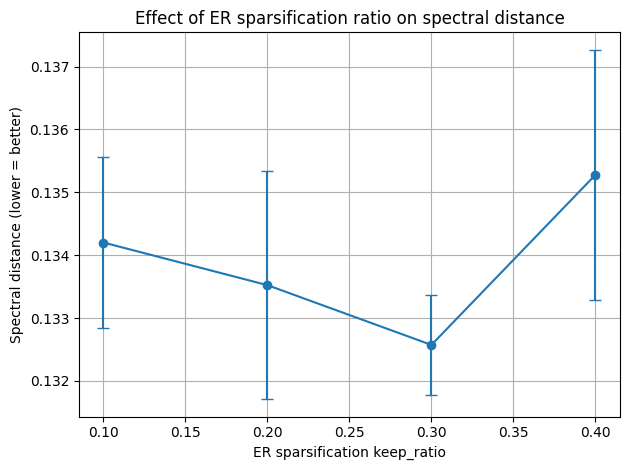

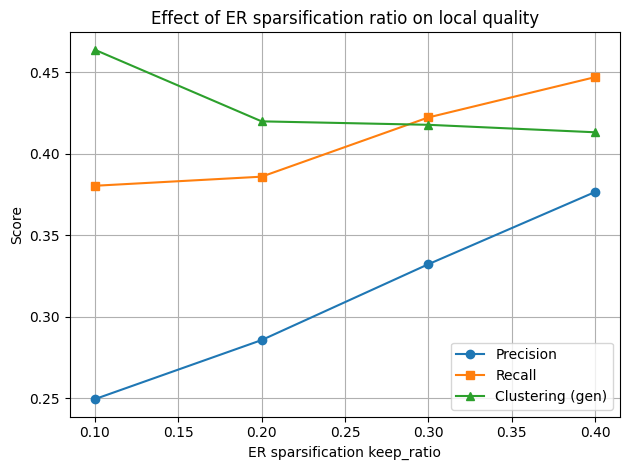


====== 计算基准线 (Baselines) ======
[基准 A] 真实图内部差异 (Real-to-Real): 0.1130
         (这是数据集的多样性，你的模型结果越接近这个值越好)
[基准 B] 随机图差异 (Real-to-Random):   0.1613
         (如果你的结果接近这个值，说明模型失败了)
Real-to-Real baseline:   0.1130
Real-to-Random baseline: 0.1613


In [15]:
if __name__ == "__main__":

    set_seed(42)

    # 1. 加载数据集
    full_dataset = load_deezer_dataset(limit=5000)

    # 过滤掉太小的图
    full_dataset = [g for g in full_dataset if g.number_of_nodes() > 10]
    print(f"有效数据集大小: {len(full_dataset)}")

    # 2. 划分训练 / 测试集
    split_idx = int(len(full_dataset) * 0.8)
    train_graphs = full_dataset[:split_idx]
    test_graphs = full_dataset[split_idx:]

    print(f"训练集数量: {len(train_graphs)}, 测试集数量: {len(test_graphs)}")

    # 3. 训练 GNN (只训一次，所有 keep_ratio 共用同一个 scorer)
    trained_gnn, feat_dim = train_gnn_scorer(train_graphs, epochs=200, lr=0.002)

    # 4. 实验：不同 ER keep_ratio
    keep_ratios = [0.1, 0.2, 0.3, 0.4]
    n_repeats = 3   # 每个比例重复几次，减小随机性

    results = []

    for kr in keep_ratios:
        spec_list = []
        prec_list = []
        rec_list = []
        clus_gen_list = []

        for r in range(n_repeats):
            # 为了有随机性，又可复现：每次稍微改 seed
            set_seed(42 + r)

            summary = evaluate_once(
                test_graphs=test_graphs,
                trained_gnn=trained_gnn,
                feat_dim=feat_dim,
                keep_ratio=kr,
                steps_forward=2,
                steps_reverse=10,
                motif_bonus=5.0,
                candidate_mode='all'
            )

            spec_list.append(summary["avg_spec"])
            prec_list.append(summary["avg_prec"])
            rec_list.append(summary["avg_rec"])
            clus_gen_list.append(summary["avg_clus_gen"])

        results.append({
            "keep_ratio": kr,
            "spec_mean": float(np.mean(spec_list)),
            "spec_std": float(np.std(spec_list)),
            "prec_mean": float(np.mean(prec_list)),
            "rec_mean": float(np.mean(rec_list)),
            "clus_gen_mean": float(np.mean(clus_gen_list)),
        })

    # 5. 画折线图：横轴 keep_ratio，纵轴 谱距离（越低越好）
    ratios = [r["keep_ratio"] for r in results]
    spec_means = [r["spec_mean"] for r in results]
    spec_stds = [r["spec_std"] for r in results]

    plt.figure()
    plt.errorbar(ratios, spec_means, yerr=spec_stds, marker='o', capsize=4)
    plt.xlabel("ER sparsification keep_ratio")
    plt.ylabel("Spectral distance (lower = better)")
    plt.title("Effect of ER sparsification ratio on spectral distance")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # 如果你也想看 Precision / Recall 的趋势，可以再画一张图：
    prec_means = [r["prec_mean"] for r in results]
    rec_means = [r["rec_mean"] for r in results]
    clus_means = [r["clus_gen_mean"] for r in results]

    plt.figure()
    plt.plot(ratios, prec_means, marker='o', label="Precision")
    plt.plot(ratios, rec_means, marker='s', label="Recall")
    plt.plot(ratios, clus_means, marker='^', label="Clustering (gen)")
    plt.xlabel("ER sparsification keep_ratio")
    plt.ylabel("Score")
    plt.title("Effect of ER sparsification ratio on local quality")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # （可选）只算一次基准线即可，因为和 keep_ratio 无关
    baseline_real, baseline_rand = calculate_baselines(test_graphs)
    print(f"Real-to-Real baseline:   {baseline_real:.4f}")
    print(f"Real-to-Random baseline: {baseline_rand:.4f}")
